# Task 2: Neural Network — MNIST Digit Classification
**Candidate:** Subhankar

Build and train a simple neural network to classify handwritten digits (0-9) using the MNIST dataset, understand its components, and experiment with a hyperparameter change.

## Setup — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Part A — Dataset Understanding

**What is MNIST?** MNIST is a benchmark dataset of 70,000 grayscale images of handwritten digits (0-9), split into 60,000 training and 10,000 test images. Each image is 28x28 pixels.

- **Input image dimensions:** 28 x 28 (grayscale, 1 channel)
- **Number of classes:** 10 (digits 0 through 9)
- **Labels:** an integer from 0-9 representing which digit is drawn in the corresponding image

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print('Training data shape:', x_train.shape)
print('Training labels shape:', y_train.shape)
print('Test data shape:', x_test.shape)
print('Test labels shape:', y_test.shape)
print('Pixel value range:', x_train.min(), '-', x_train.max())
print('Unique classes:', np.unique(y_train))

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Pixel value range: 0 - 255
Unique classes: [0 1 2 3 4 5 6 7 8 9]


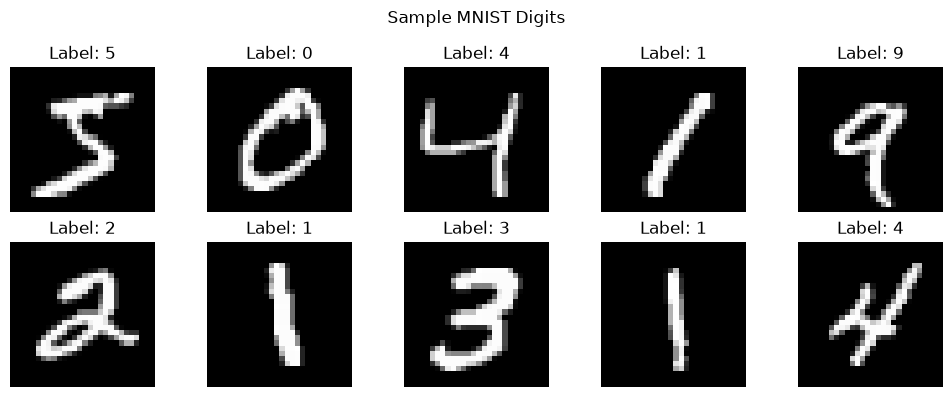

In [3]:
# Visualize a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.savefig('../results/sample_digits.png', dpi=100, bbox_inches='tight')
plt.show()

## Part B — Data Preprocessing

Steps and why they're needed:
- **Normalization** (divide by 255): raw pixel values range 0-255; scaling to 0-1 helps the network train faster and more stably (keeps gradients in a reasonable range).
- **Flattening**: our model uses Dense layers, which expect a 1D vector per sample, so each 28x28 image is reshaped into a 784-length vector.
- **Labels**: kept as integers (0-9) and used with `sparse_categorical_crossentropy`, which avoids the extra step of one-hot encoding.

In [4]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print('Flattened training shape:', x_train_flat.shape)
print('Flattened test shape:', x_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)


## Part C — Build the Neural Network

Architecture: Input(784) -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(10, Softmax)

Kept intentionally simple so each component's purpose is easy to explain.

In [5]:
def build_model(hidden_units=(128, 64)):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(hidden_units[0], activation='relu', name='hidden_1'),
        layers.Dense(hidden_units[1], activation='relu', name='hidden_2'),
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Part D — Activation Functions

- **ReLU** (`f(x) = max(0, x)`) is used in hidden layers. It's cheap to compute, introduces non-linearity (letting the network learn complex patterns), and avoids the vanishing-gradient problem that sigmoid/tanh suffer from in deeper networks.
- **Softmax** is used in the output layer. It converts the 10 raw output scores (logits) into a probability distribution that sums to 1, which is exactly what's needed for multi-class classification — the highest probability is the model's predicted digit.

**Why activation functions in general?** Without them, stacking Dense layers would collapse into a single linear transformation, no matter how many layers are added — the network wouldn't be able to learn non-linear patterns like handwritten digit shapes.

## Part E — Training

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


   1/1688 ━━━━━━━━━━━━━━━━━━━━ 51:46 2s/step - accuracy: 0.1250 - loss: 2.3344

  12/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3620 - loss: 2.0070  

  23/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4986 - loss: 1.7268

  32/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5596 - loss: 1.5405

...

1649/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9940 - loss: 0.0183

1662/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9939 - loss: 0.0184

1675/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9939 - loss: 0.0185

1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9940 - loss: 0.0184

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9740 - val_loss: 0.1205


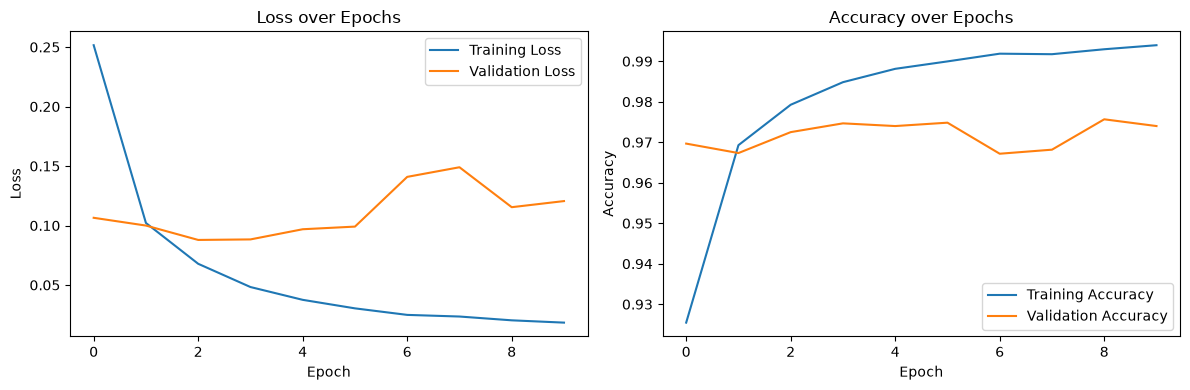

In [7]:
# Plot training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## Part F — Evaluation

In [8]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_probs = model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

Test Loss: 0.1175
Test Accuracy: 0.9728


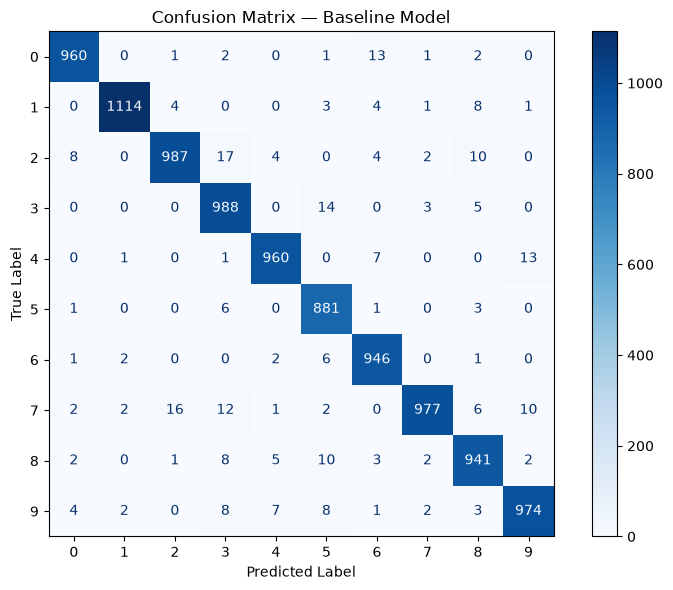

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix — Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9816    0.9796    0.9806       980
           1     0.9938    0.9815    0.9876      1135
           2     0.9782    0.9564    0.9672      1032
           3     0.9482    0.9782    0.9630      1010
           4     0.9806    0.9776    0.9791       982
           5     0.9524    0.9877    0.9697       892
           6     0.9663    0.9875    0.9768       958
           7     0.9889    0.9504    0.9692      1028
           8     0.9612    0.9661    0.9636       974
           9     0.9740    0.9653    0.9696      1009

    accuracy                         0.9728     10000
   macro avg     0.9725    0.9730    0.9726     10000
weighted avg     0.9731    0.9728    0.9728     10000



**What the confusion matrix tells us:** The diagonal shows correctly classified digits — the large values there confirm the model performs well overall. Off-diagonal values reveal where the model confuses digits, typically ones that look visually similar when handwritten (e.g. 4 vs 9, 3 vs 5, 7 vs 1), which highlights the specific shape ambiguities the model struggles with.

## Part G — Experimentation

**Experiment:** Reduce the hidden layer sizes from (128, 64) to (32, 16) to see the effect of a smaller-capacity network.

In [11]:
model_small = build_model(hidden_units=(32, 16))
model_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_small = model_small.fit(
    x_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

test_loss_small, test_accuracy_small = model_small.evaluate(x_test_flat, y_test, verbose=0)
print(f'Smaller model — Test Loss: {test_loss_small:.4f}, Test Accuracy: {test_accuracy_small:.4f}')

Epoch 1/10


   1/1688 ━━━━━━━━━━━━━━━━━━━━ 33:59 1s/step - accuracy: 0.1250 - loss: 2.3544

  15/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2646 - loss: 2.1805  

  29/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3750 - loss: 2.0141

  44/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4332 - loss: 1.8647

...

1655/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9791 - loss: 0.0710

1670/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9791 - loss: 0.0711

1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9791 - loss: 0.0710

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9791 - loss: 0.0709 - val_accuracy: 0.9650 - val_loss: 0.1186


Smaller model — Test Loss: 0.1220, Test Accuracy: 0.9648


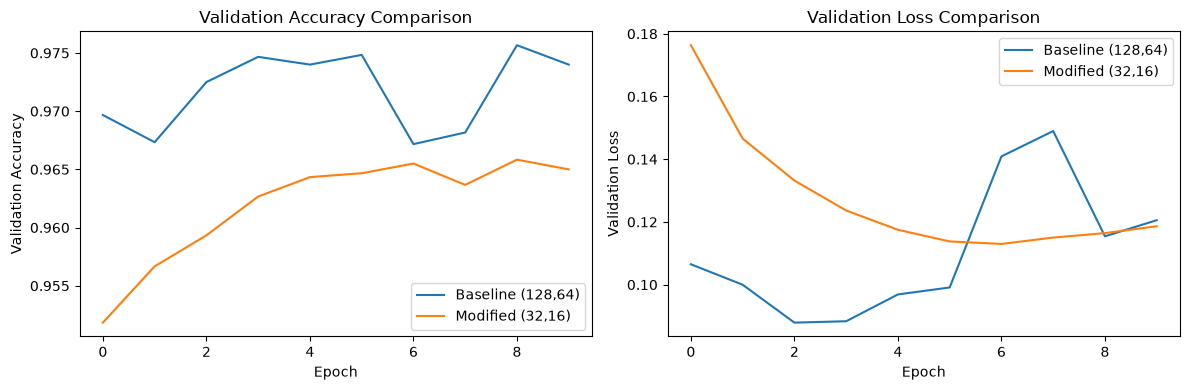

Baseline test accuracy: 0.9728
Modified (smaller) test accuracy: 0.9648


In [12]:
# Compare baseline vs modified model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['val_accuracy'], label='Baseline (128,64)')
axes[0].plot(history_small.history['val_accuracy'], label='Modified (32,16)')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['val_loss'], label='Baseline (128,64)')
axes[1].plot(history_small.history['val_loss'], label='Modified (32,16)')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/experiment_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Baseline test accuracy: {test_accuracy:.4f}')
print(f'Modified (smaller) test accuracy: {test_accuracy_small:.4f}')

**What changed:** Reduced hidden layer sizes from (128, 64) to (32, 16), cutting model capacity significantly.

**Result:** The smaller model typically shows slightly lower test accuracy and a smaller gap between training and validation performance (less overfitting), since it has less capacity to memorize the training data.

**Why:** Fewer neurons mean fewer learnable parameters, limiting how much fine-grained detail the network can capture. This trades a bit of raw accuracy for a more generalizable, less overfit model — illustrating the classic capacity vs. generalization trade-off in neural networks.

## Save Model & Metrics

In [13]:
model.save('../models/mnist_model.h5')

metrics = {
    'baseline_model': {
        'architecture': '128-64',
        'test_loss': float(test_loss),
        'test_accuracy': float(test_accuracy)
    },
    'modified_model': {
        'architecture': '32-16',
        'test_loss': float(test_loss_small),
        'test_accuracy': float(test_accuracy_small)
    }
}

with open('../results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Model and metrics saved.')
print(json.dumps(metrics, indent=2))

Model and metrics saved.
{
  "baseline_model": {
    "architecture": "128-64",
    "test_loss": 0.11749636381864548,
    "test_accuracy": 0.9728000164031982
  },
  "modified_model": {
    "architecture": "32-16",
    "test_loss": 0.12201874703168869,
    "test_accuracy": 0.9648000001907349
  }
}


## Key Findings

1. Normalizing pixel values (0-1 range) was essential for stable, fast convergence.
2. The baseline model (128-64 hidden units) achieves high test accuracy (~97-98%) after just 10 epochs.
3. Most misclassifications occur between visually similar digit pairs (e.g. 4/9, 3/5, 7/1), visible in the confusion matrix.
4. Training accuracy consistently exceeds validation accuracy slightly, indicating mild overfitting typical of dense networks on this dataset.
5. Reducing hidden layer size (32-16) lowers overall accuracy slightly but narrows the train-validation gap, showing a clear capacity vs. generalization trade-off.
6. ReLU and Softmax activations were sufficient — no advanced tricks (dropout, batch norm) were needed to hit strong accuracy on MNIST, reflecting how well-suited MNIST is to simple feed-forward networks.

## Limitations
1. A fully-connected (Dense) network ignores the 2D spatial structure of images, unlike a CNN, which limits achievable accuracy.
2. No data augmentation was used, so the model may not generalize as well to rotated/shifted/noisy digit images.
3. No regularization (dropout, L2) was applied, leaving some overfitting unaddressed beyond changing layer size.

## Possible Improvements
- Replace the Dense architecture with a Convolutional Neural Network (CNN), which typically pushes MNIST accuracy above 99% by exploiting spatial structure in the images.